In [6]:
from google.colab import files
uploaded = files.upload()

Saving test_set (1).zip to test_set (1).zip


In [7]:
import zipfile

with zipfile.ZipFile('/content/test_set (1).zip', 'r') as zip_ref:
    zip_ref.extractall('/content/dataset')

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [8]:
import os

for root, dirs, files in os.walk("/content/dataset"):
    print(root)
    print("Folders:", dirs[:5])
    print("Files:", files[:5])
    print("-"*50)

/content/dataset
Folders: ['test_set']
Files: []
--------------------------------------------------
/content/dataset/test_set
Folders: ['cats', 'dogs']
Files: []
--------------------------------------------------
/content/dataset/test_set/cats
Folders: []
Files: ['cat.4442.jpg', 'cat.4866.jpg', 'cat.4501.jpg', 'cat.4167.jpg', 'cat.4733.jpg']
--------------------------------------------------
/content/dataset/test_set/dogs
Folders: []
Files: ['dog.4835.jpg', 'dog.4010.jpg', 'dog.4871.jpg', 'dog.4494.jpg', 'dog.4061.jpg']
--------------------------------------------------


In [9]:
import os
import cv2
import numpy as np

data = []
labels = []

dataset_path = "/content/dataset/test_set"

for category in ["cats", "dogs"]:

    folder = os.path.join(dataset_path, category)

    label = 0 if category == "cats" else 1

    count = 0

    for img_name in os.listdir(folder):

        if count >= 200:   # only 200 images per class
            break

        try:
            img_path = os.path.join(folder, img_name)

            img = cv2.imread(img_path)
            img = cv2.resize(img, (32, 32))

            data.append(img.flatten())
            labels.append(label)

            count += 1

        except:
            pass

X = np.array(data)
y = np.array(labels)

print("X Shape:", X.shape)
print("Y Shape:", y.shape)

X Shape: (400, 3072)
Y Shape: (400,)


In [11]:
X = X / 255.0

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(320, 3072)
(80, 3072)


In [13]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC(
    max_iter=1000,
    dual=False,
    random_state=42
)

svm_model.fit(X_train, y_train)

print("SVM Model Trained Successfully")

SVM Model Trained Successfully


In [14]:
from sklearn.metrics import accuracy_score

y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy * 100)

Accuracy: 48.75


In [15]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[ 9 35]
 [ 6 30]]


In [16]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.20      0.31        44
           1       0.46      0.83      0.59        36

    accuracy                           0.49        80
   macro avg       0.53      0.52      0.45        80
weighted avg       0.54      0.49      0.44        80



In [18]:
import joblib

joblib.dump(svm_model, "cats_dogs_svm.pkl")

print("Model Saved Successfully")

Model Saved Successfully


In [21]:
print("Min value:", sample.min())
print("Max value:", sample.max())
print("Shape:", sample.shape)

Min value: 0.00015378700499807767
Max value: 0.00392156862745098
Shape: (3072,)


In [22]:
import numpy as np

print(np.unique(sample[:100]))

[0.00155325 0.00158401 0.00161476 0.00163014 0.00164552 0.0016609
 0.00167628 0.00169166 0.00170704 0.00172241 0.00173779 0.00175317
 0.00176855 0.00178393 0.00179931 0.00181469 0.00183007 0.00184544
 0.00186082 0.0018762  0.00189158 0.00192234 0.00193772 0.00195309
 0.00196847 0.00198385 0.00202999 0.00206075 0.0020915  0.00210688
 0.00212226 0.00213764 0.00218378 0.00221453 0.00222991 0.00224529
 0.00230681 0.00233756 0.00236832 0.00239908 0.00241446 0.00244521
 0.00247597 0.00250673 0.00256824 0.00258362 0.00261438 0.00267589
 0.00272203 0.00275279 0.00279892 0.0028143  0.00290657 0.00335256
 0.00336794 0.00338331 0.00358324 0.00376778 0.00389081 0.00390619
 0.00392157]


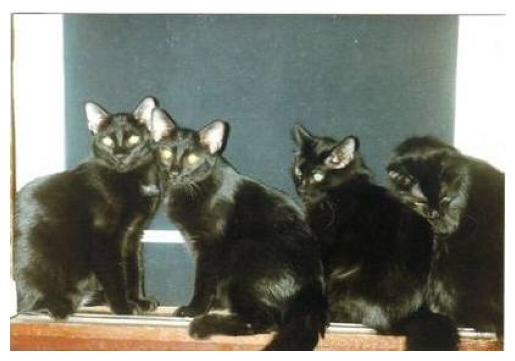

In [23]:
import cv2
import matplotlib.pyplot as plt

img_path = "/content/dataset/test_set/cats/" + os.listdir("/content/dataset/test_set/cats")[0]

img = cv2.imread(img_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

In [24]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[ 9 35]
 [ 6 30]]


In [25]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.20      0.31        44
           1       0.46      0.83      0.59        36

    accuracy                           0.49        80
   macro avg       0.53      0.52      0.45        80
weighted avg       0.54      0.49      0.44        80



In [26]:
import joblib

joblib.dump(svm_model, "cats_dogs_svm.pkl")

print("Model Saved Successfully")

Model Saved Successfully
